# Black Pepper Leaf Disease Classification

This notebook trains a CNN model to classify 6 different black pepper leaf conditions:
1. Footrot
2. Pollu Disease
3. Slow-Decline
4. Healthy
5. Leaf Blight
6. Yellow Mottle Virus

## Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import cv2
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


f:\black-pepper-disease-identification-model-main\black-pepper-disease-identification-model-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration and Hyperparameters

In [2]:
# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
CHANNELS = 3

# Training parameters
EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

# Data augmentation parameters
ROTATION_RANGE = 20
ZOOM_RANGE = 0.15
WIDTH_SHIFT = 0.1
HEIGHT_SHIFT = 0.1

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Data Loading and Initial Exploration

In [3]:
# Download datasets
first_dataset = kagglehub.dataset_download(
    "udi17live/black-pepper-leaf-blight-and-yellow-mottle-virus"
)
second_dataset = kagglehub.dataset_download(
    "adithyantg/black-pepper-leaf-disease-mini-dataset"
)

print("Dataset 1 path:", first_dataset)
print("Dataset 2 path:", second_dataset)

Dataset 1 path: C:\Users\user\.cache\kagglehub\datasets\udi17live\black-pepper-leaf-blight-and-yellow-mottle-virus\versions\1
Dataset 2 path: C:\Users\user\.cache\kagglehub\datasets\adithyantg\black-pepper-leaf-disease-mini-dataset\versions\1


In [4]:
def find_class_root(dataset_path):
    """Find the root directory containing class folders."""
    subdirs = [
        os.path.join(dataset_path, d)
        for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ]

    if len(subdirs) == 1:
        inner = subdirs[0]
        inner_subdirs = [
            d for d in os.listdir(inner)
            if os.path.isdir(os.path.join(inner, d))
        ]
        if len(inner_subdirs) > 1:
            return inner

    return dataset_path

dataset1_root = find_class_root(first_dataset)
dataset2_root = find_class_root(second_dataset)

print("Dataset 1 root:", dataset1_root)
print("Dataset 2 root:", dataset2_root)

Dataset 1 root: C:\Users\user\.cache\kagglehub\datasets\udi17live\black-pepper-leaf-blight-and-yellow-mottle-virus\versions\1
Dataset 2 root: C:\Users\user\.cache\kagglehub\datasets\adithyantg\black-pepper-leaf-disease-mini-dataset\versions\1\BLACK_PEPPER_DATASET


In [5]:
def get_classes(dataset_root):
    """Get list of class folders."""
    return [
        d for d in os.listdir(dataset_root)
        if os.path.isdir(os.path.join(dataset_root, d))
    ]

classes_1 = get_classes(dataset1_root)
classes_2 = get_classes(dataset2_root)

print("Dataset 1 classes:", classes_1)
print("Dataset 2 classes:", classes_2)

Dataset 1 classes: ['black_pepper_healthy', 'black_pepper_leaf_blight', 'black_pepper_yellow_mottle_virus']
Dataset 2 classes: ['Footrot', 'Pollu_Disease', 'Slow-Decline']


In [6]:
# Create unified class list
all_classes = sorted(list(set(classes_1 + classes_2)))
print("\nUnified classes (6 total):")
for i, cls in enumerate(all_classes):
    print(f"{i}: {cls}")

class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
class_names = all_classes


Unified classes (6 total):
0: Footrot
1: Pollu_Disease
2: Slow-Decline
3: black_pepper_healthy
4: black_pepper_leaf_blight
5: black_pepper_yellow_mottle_virus


In [7]:
# Collect all image paths and labels
image_paths = []
labels = []

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

def add_dataset(dataset_root):
    """Add images from a dataset to the collection."""
    for cls in os.listdir(dataset_root):
        cls_path = os.path.join(dataset_root, cls)

        if not os.path.isdir(cls_path):
            continue

        if cls not in class_to_idx:
            print(f"[WARNING] Skipping unknown class: {cls}")
            continue

        for img in os.listdir(cls_path):
            if not img.lower().endswith(VALID_EXTENSIONS):
                continue

            img_path = os.path.join(cls_path, img)
            image_paths.append(img_path)
            labels.append(class_to_idx[cls])

add_dataset(dataset1_root)
add_dataset(dataset2_root)

print(f"\nTotal images collected: {len(image_paths)}")
print(f"Total labels: {len(labels)}")


Total images collected: 2319
Total labels: 2319


## Class Distribution Analysis


Class distribution:
Footrot: 500 images (21.56%)
Pollu_Disease: 500 images (21.56%)
Slow-Decline: 500 images (21.56%)
black_pepper_healthy: 273 images (11.77%)
black_pepper_leaf_blight: 273 images (11.77%)
black_pepper_yellow_mottle_virus: 273 images (11.77%)


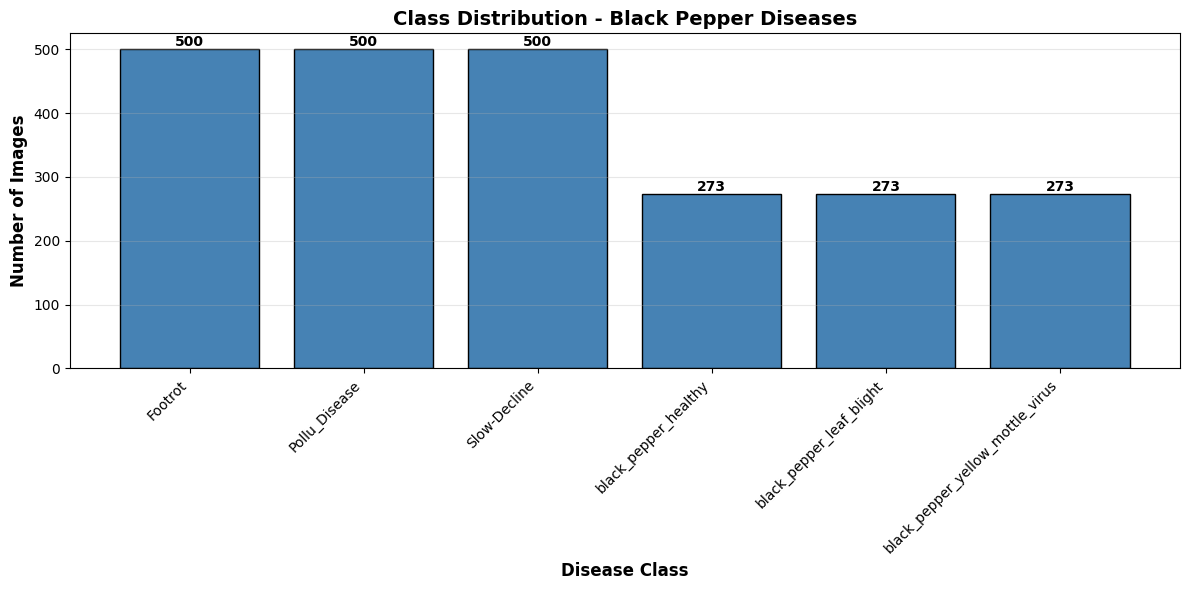


Class imbalance ratio: 1.83:1
Maximum class size: 500
Minimum class size: 273


In [8]:
# Analyze class distribution
label_counts = Counter(labels)
print("\nClass distribution:")
for idx in sorted(label_counts.keys()):
    cls_name = idx_to_class[idx]
    count = label_counts[idx]
    print(f"{cls_name}: {count} images ({count/len(labels)*100:.2f}%)")

# Visualize class distribution
plt.figure(figsize=(12, 6))
class_labels = [idx_to_class[i] for i in sorted(label_counts.keys())]
class_counts = [label_counts[i] for i in sorted(label_counts.keys())]

bars = plt.bar(class_labels, class_counts, color='steelblue', edgecolor='black')
plt.xlabel('Disease Class', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Class Distribution - Black Pepper Diseases', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Check imbalance ratio
max_count = max(class_counts)
min_count = min(class_counts)
imbalance_ratio = max_count / min_count
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Maximum class size: {max_count}")
print(f"Minimum class size: {min_count}")

## Sample Images Visualization

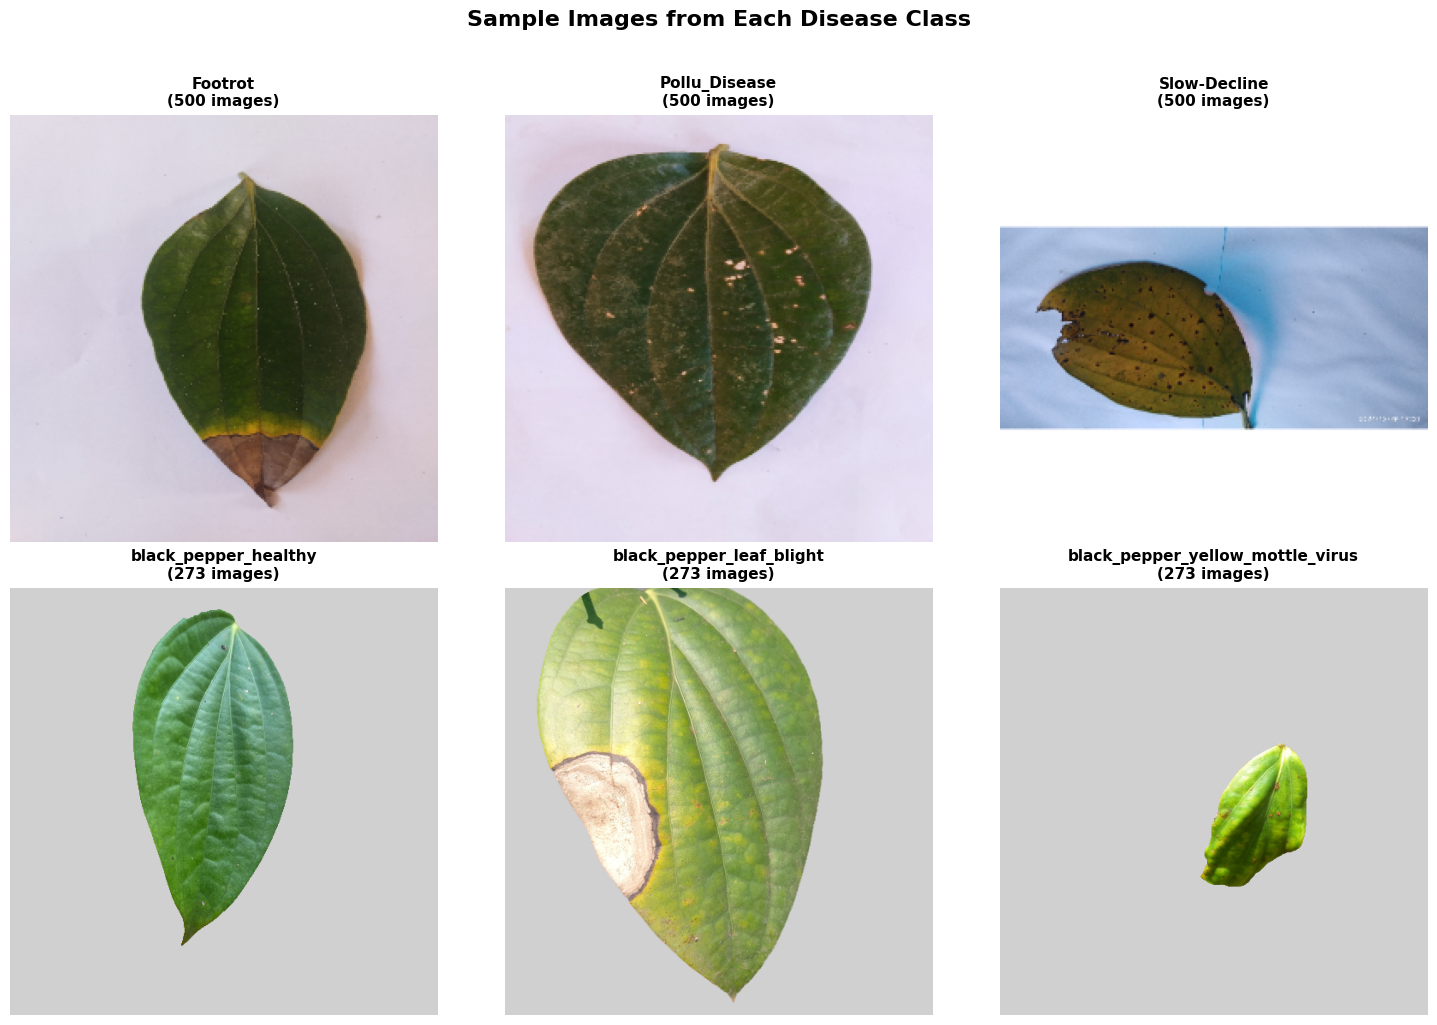

In [9]:
# Display sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, cls_name in enumerate(class_names):
    # Find first image of this class
    cls_idx = class_to_idx[cls_name]
    img_idx = labels.index(cls_idx)
    img_path = image_paths[img_idx]
    
    # Load and display image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'{cls_name}\n({label_counts[cls_idx]} images)', 
                        fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Disease Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Data Preprocessing and Augmentation

In [10]:
# Split data into train, validation, and test sets
# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=TEST_SPLIT, 
    stratify=labels,
    random_state=SEED
)

# Second split: separate train and validation
val_size = VALIDATION_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size,
    stratify=y_temp,
    random_state=SEED
)

print(f"\nData split:")
print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

# Verify class distribution in splits
print("\nTraining set distribution:")
train_dist = Counter(y_train)
for idx in sorted(train_dist.keys()):
    print(f"  {idx_to_class[idx]}: {train_dist[idx]}")


Data split:
Training set: 1623 images
Validation set: 464 images
Test set: 232 images

Training set distribution:
  Footrot: 350
  Pollu_Disease: 350
  Slow-Decline: 350
  black_pepper_healthy: 191
  black_pepper_leaf_blight: 191
  black_pepper_yellow_mottle_virus: 191



Class weights for handling imbalance:
Footrot: 0.7729
Pollu_Disease: 0.7729
Slow-Decline: 0.7729
black_pepper_healthy: 1.4162
black_pepper_leaf_blight: 1.4162
black_pepper_yellow_mottle_virus: 1.4162


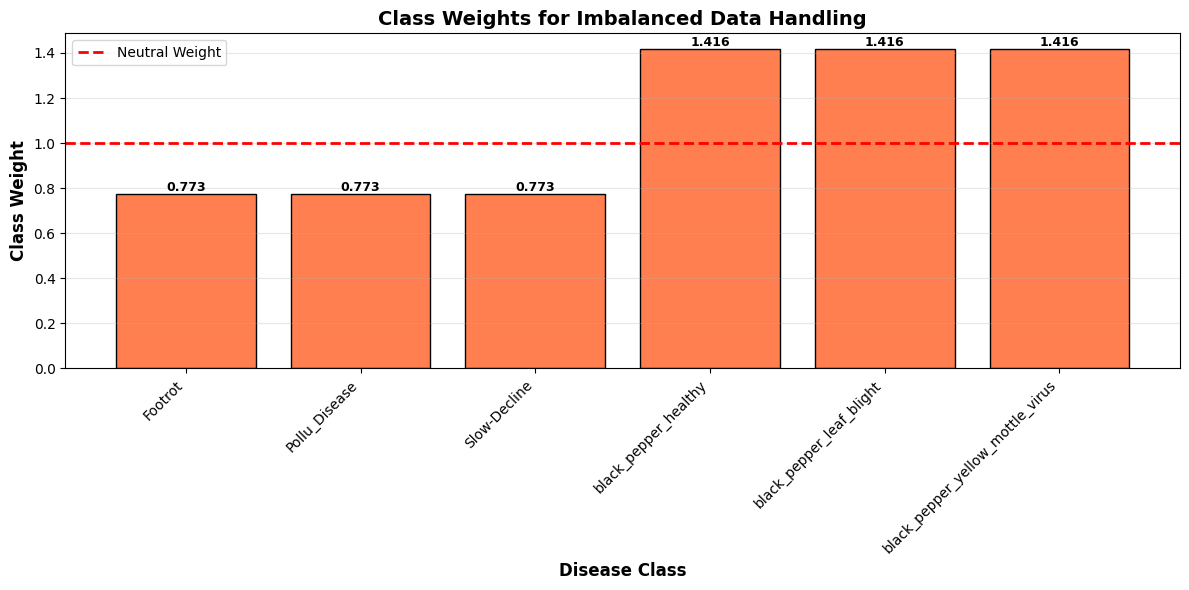

In [11]:
# Calculate class weights for imbalanced data
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("\nClass weights for handling imbalance:")
for idx, weight in class_weights.items():
    print(f"{idx_to_class[idx]}: {weight:.4f}")

# Visualize class weights
plt.figure(figsize=(12, 6))
weight_labels = [idx_to_class[i] for i in sorted(class_weights.keys())]
weight_values = [class_weights[i] for i in sorted(class_weights.keys())]

bars = plt.bar(weight_labels, weight_values, color='coral', edgecolor='black')
plt.xlabel('Disease Class', fontsize=12, fontweight='bold')
plt.ylabel('Class Weight', fontsize=12, fontweight='bold')
plt.title('Class Weights for Imbalanced Data Handling', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Neutral Weight')
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Add weight labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
def load_and_preprocess_image(img_path, label):
    """Load and preprocess a single image."""
    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize to target dimensions
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    
    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    return img, label

# Load all images
print("\nLoading and preprocessing images...")
print("This may take a few minutes...")

X_train_loaded = []
for img_path in X_train:
    img, _ = load_and_preprocess_image(img_path, 0)
    X_train_loaded.append(img)
X_train_loaded = np.array(X_train_loaded)
y_train_array = np.array(y_train)

X_val_loaded = []
for img_path in X_val:
    img, _ = load_and_preprocess_image(img_path, 0)
    X_val_loaded.append(img)
X_val_loaded = np.array(X_val_loaded)
y_val_array = np.array(y_val)

X_test_loaded = []
for img_path in X_test:
    img, _ = load_and_preprocess_image(img_path, 0)
    X_test_loaded.append(img)
X_test_loaded = np.array(X_test_loaded)
y_test_array = np.array(y_test)

print(f"\nImages loaded successfully!")
print(f"Training data shape: {X_train_loaded.shape}")
print(f"Validation data shape: {X_val_loaded.shape}")
print(f"Test data shape: {X_test_loaded.shape}")


Loading and preprocessing images...
This may take a few minutes...

Images loaded successfully!
Training data shape: (1623, 224, 224, 3)
Validation data shape: (464, 224, 224, 3)
Test data shape: (232, 224, 224, 3)


In [13]:
# Data augmentation for training set only
train_datagen = ImageDataGenerator(
    rotation_range=ROTATION_RANGE,
    width_shift_range=WIDTH_SHIFT,
    height_shift_range=HEIGHT_SHIFT,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=ZOOM_RANGE,
    fill_mode='nearest'
)

# No augmentation for validation and test sets
val_test_datagen = ImageDataGenerator()

# Create data generators
train_generator = train_datagen.flow(
    X_train_loaded, y_train_array,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow(
    X_val_loaded, y_val_array,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow(
    X_test_loaded, y_test_array,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nData generators created successfully!")
print(f"Steps per epoch (training): {len(train_generator)}")
print(f"Validation steps: {len(val_generator)}")


Data generators created successfully!
Steps per epoch (training): 51
Validation steps: 15


## Augmentation Visualization

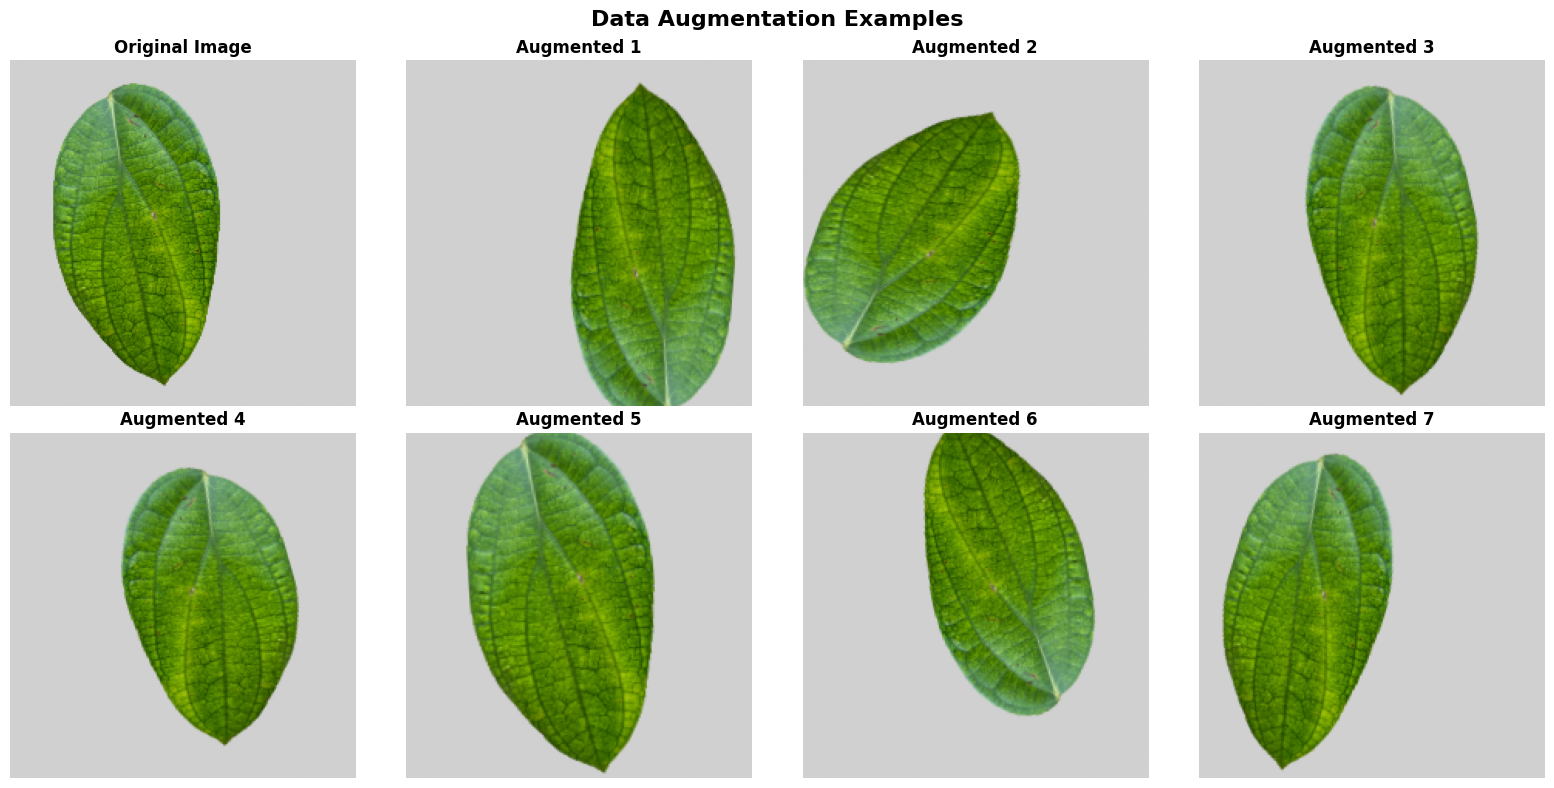

In [14]:
# Visualize augmented images
sample_img = X_train_loaded[0:1]
sample_label = y_train_array[0:1]

aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Original image
axes[0].imshow(sample_img[0])
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Augmented versions
for i in range(1, 8):
    aug_img, _ = next(aug_gen)
    axes[i].imshow(aug_img[0])
    axes[i].set_title(f'Augmented {i}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Architecture

In [15]:
def create_cnn_model(input_shape, num_classes):
    """Create a CNN model for image classification."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=input_shape, name='conv1_1'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.BatchNormalization(name='bn1'),
        layers.Dropout(0.25, name='dropout1'),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.BatchNormalization(name='bn2'),
        layers.Dropout(0.25, name='dropout2'),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
        layers.MaxPooling2D((2, 2), name='pool3'),
        layers.BatchNormalization(name='bn3'),
        layers.Dropout(0.25, name='dropout3'),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_1'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_2'),
        layers.MaxPooling2D((2, 2), name='pool4'),
        layers.BatchNormalization(name='bn4'),
        layers.Dropout(0.25, name='dropout4'),
        
        # Global pooling and dense layers
        layers.GlobalAveragePooling2D(name='global_avg_pool'),
        
        layers.Dense(512, activation='relu', name='fc1'),
        layers.BatchNormalization(name='bn5'),
        layers.Dropout(0.5, name='dropout5'),
        
        layers.Dense(256, activation='relu', name='fc2'),
        layers.BatchNormalization(name='bn6'),
        layers.Dropout(0.5, name='dropout6'),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

# Create model
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
num_classes = len(class_names)

model = create_cnn_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 56, 56, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 28, 28, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_2 (Conv2D)                │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 14, 14, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,441,702 (5.50 MB)

 Trainable params: 1,439,206 (5.49 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [16]:
# Calculate total parameters
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nModel Statistics:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")


Model Statistics:
Total parameters: 1,441,702
Trainable parameters: 1,439,206
Non-trainable parameters: 2,496


## Training Callbacks

In [17]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_pepper_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]
print("Training callbacks configured successfully!")

Training callbacks configured successfully!


## Model Training

In [18]:
# Train the model
print("\nStarting model training...")
print(f"Training for up to {EPOCHS} epochs with early stopping")
print(f"Using class weights to handle imbalance\n")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")


Starting model training...
Training for up to 50 epochs with early stopping
Using class weights to handle imbalance

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4704 - loss: 1.6237
Epoch 1: val_accuracy improved from None to 0.29095, saving model to best_pepper_model.keras

Epoch 1: finished saving model to best_pepper_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5933 - loss: 1.2496 - val_accuracy: 0.2909 - val_loss: 1.8245 - learning_rate: 0.0010
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7048 - loss: 0.8882
Epoch 2: val_accuracy improved from 0.29095 to 0.29310, saving model to best_pepper_model.keras

Epoch 2: finished saving model to best_pepper_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7086 - loss: 0.8593 - val_accuracy: 0.2931 - val_loss: 2.1693 - learning_rate: 0.0010
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7398 - loss: 0.7308
Epoch 3: val_accuracy improved from 0.29310 to 0

## Training History Visualization

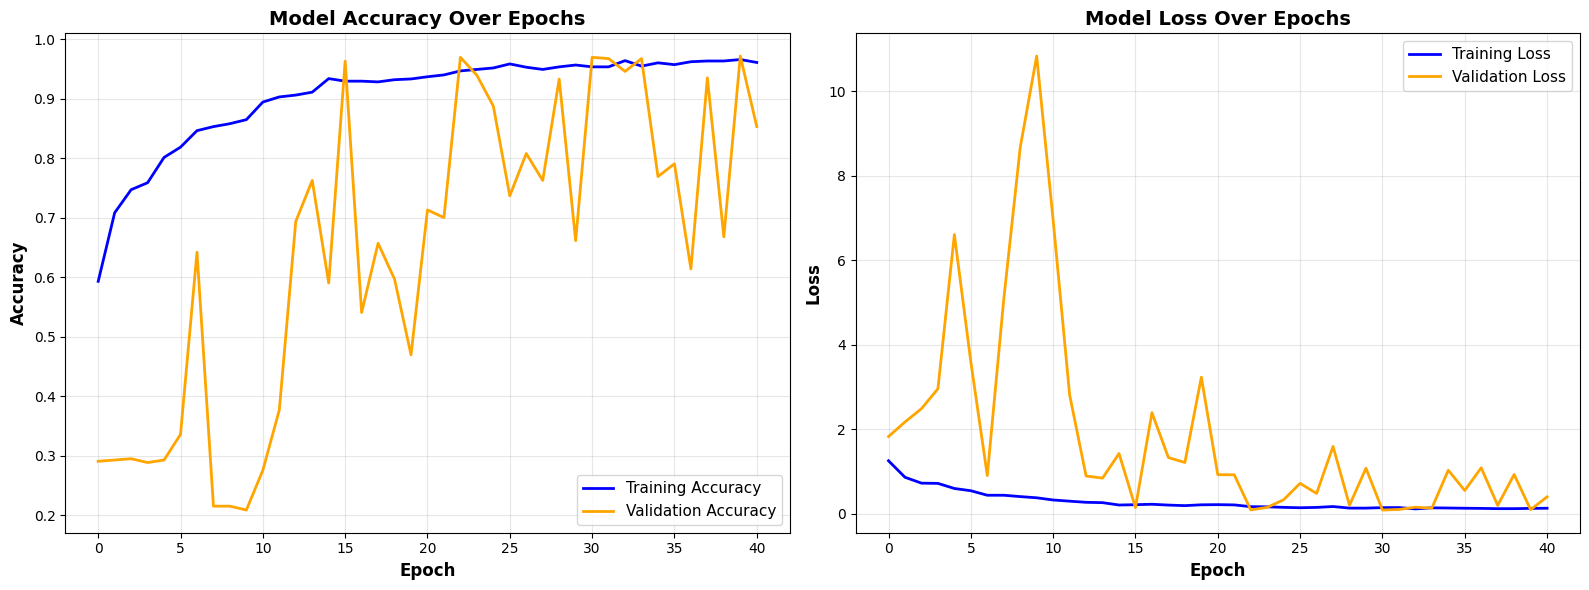


Best validation accuracy: 0.9720 at epoch 40
Best validation loss: 0.0831
Final training accuracy: 0.9612
Final validation accuracy: 0.8534


In [19]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
axes[0].plot(history.history['accuracy'], linewidth=2, label='Training Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy', color='orange')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], linewidth=2, label='Training Loss', color='blue')
axes[1].plot(history.history['val_loss'], linewidth=2, label='Validation Loss', color='orange')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best metrics
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f} at epoch {best_epoch + 1}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Model Evaluation on Test Set

In [20]:
# Evaluate on test set
print("\nEvaluating model on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Evaluating model on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 724ms/step - accuracy: 0.9698 - loss: 0.1084

Test Results:
Test Loss: 0.1084
Test Accuracy: 0.9698 (96.98%)


## Generate Predictions for Confusion Matrix and Classification Report

In [21]:
# Generate predictions
print("\nGenerating predictions on test set...")
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test_array

print(f"Predictions generated for {len(y_pred)} test images")


Generating predictions on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 767ms/step
Predictions generated for 232 test images


## Confusion Matrix

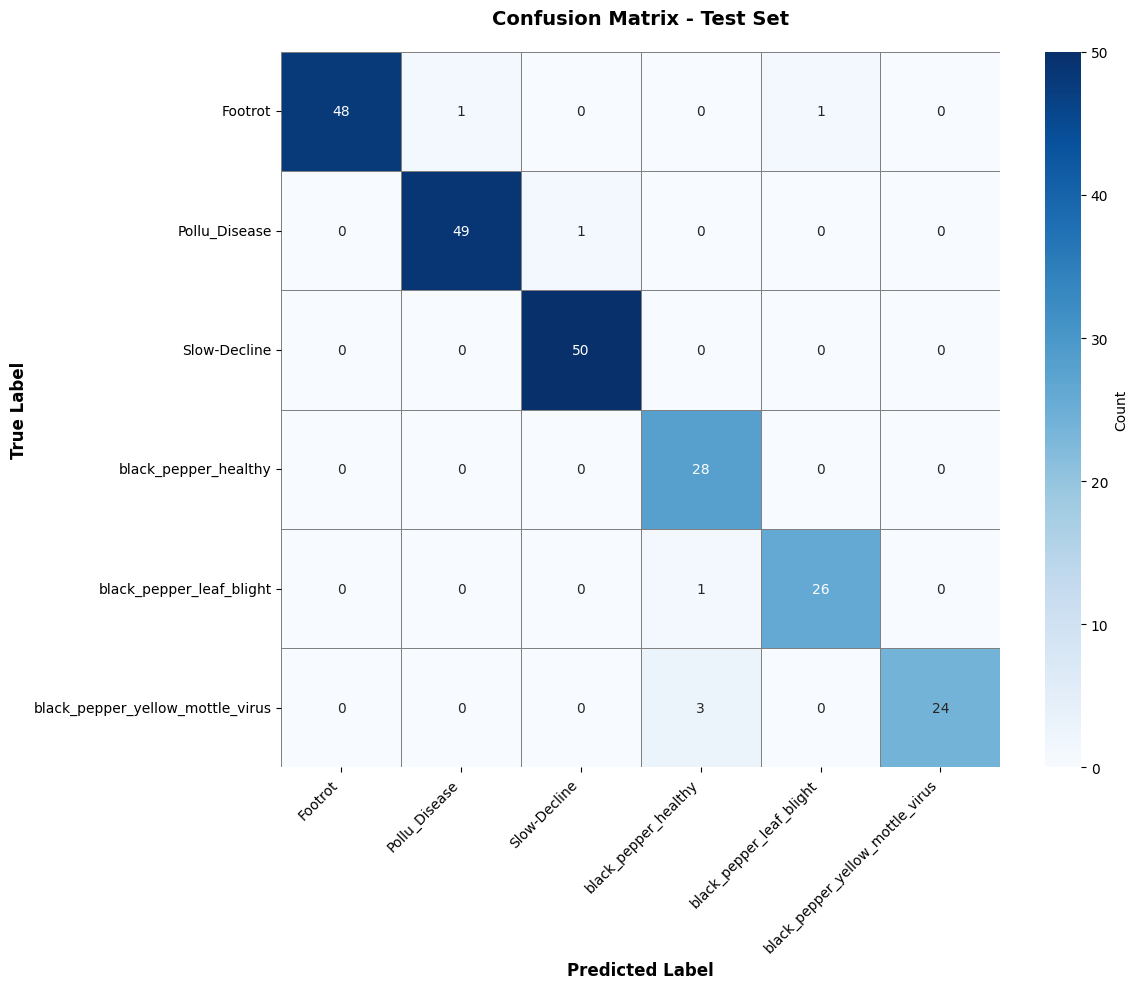


Per-Class Accuracy from Confusion Matrix:
Footrot: 0.9600 (96.00%)
Pollu_Disease: 0.9800 (98.00%)
Slow-Decline: 1.0000 (100.00%)
black_pepper_healthy: 1.0000 (100.00%)
black_pepper_leaf_blight: 0.9630 (96.30%)
black_pepper_yellow_mottle_virus: 0.8889 (88.89%)


In [22]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy from confusion matrix
print("\nPer-Class Accuracy from Confusion Matrix:")
for i, cls_name in enumerate(class_names):
    class_accuracy = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"{cls_name}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

## Normalized Confusion Matrix

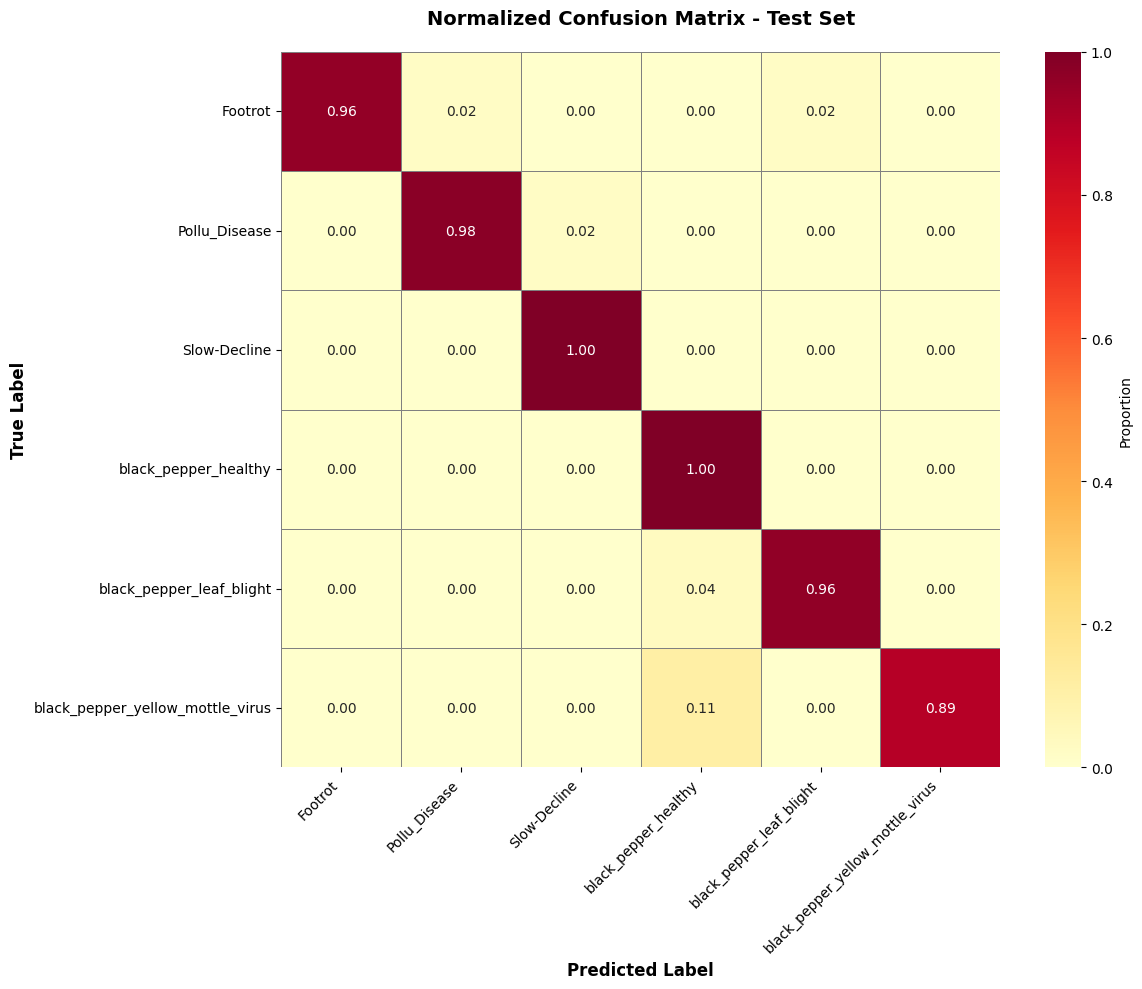

In [23]:
# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'},
            linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Classification Report

In [24]:
# Generate classification report
print("\nClassification Report:")
print("=" * 80)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Create a more detailed report as DataFrame
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

report_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nDetailed Metrics by Class:")
print(report_df.to_string(index=False))


Classification Report:
                                  precision    recall  f1-score   support

                         Footrot     1.0000    0.9600    0.9796        50
                   Pollu_Disease     0.9800    0.9800    0.9800        50
                    Slow-Decline     0.9804    1.0000    0.9901        50
            black_pepper_healthy     0.8750    1.0000    0.9333        28
        black_pepper_leaf_blight     0.9630    0.9630    0.9630        27
black_pepper_yellow_mottle_virus     1.0000    0.8889    0.9412        27

                        accuracy                         0.9698       232
                       macro avg     0.9664    0.9653    0.9645       232
                    weighted avg     0.9721    0.9698    0.9700       232


Detailed Metrics by Class:
                           Class  Precision   Recall  F1-Score  Support
                         Footrot   1.000000 0.960000  0.979592       50
                   Pollu_Disease   0.980000 0.980000  0.98000

## Metrics Visualization

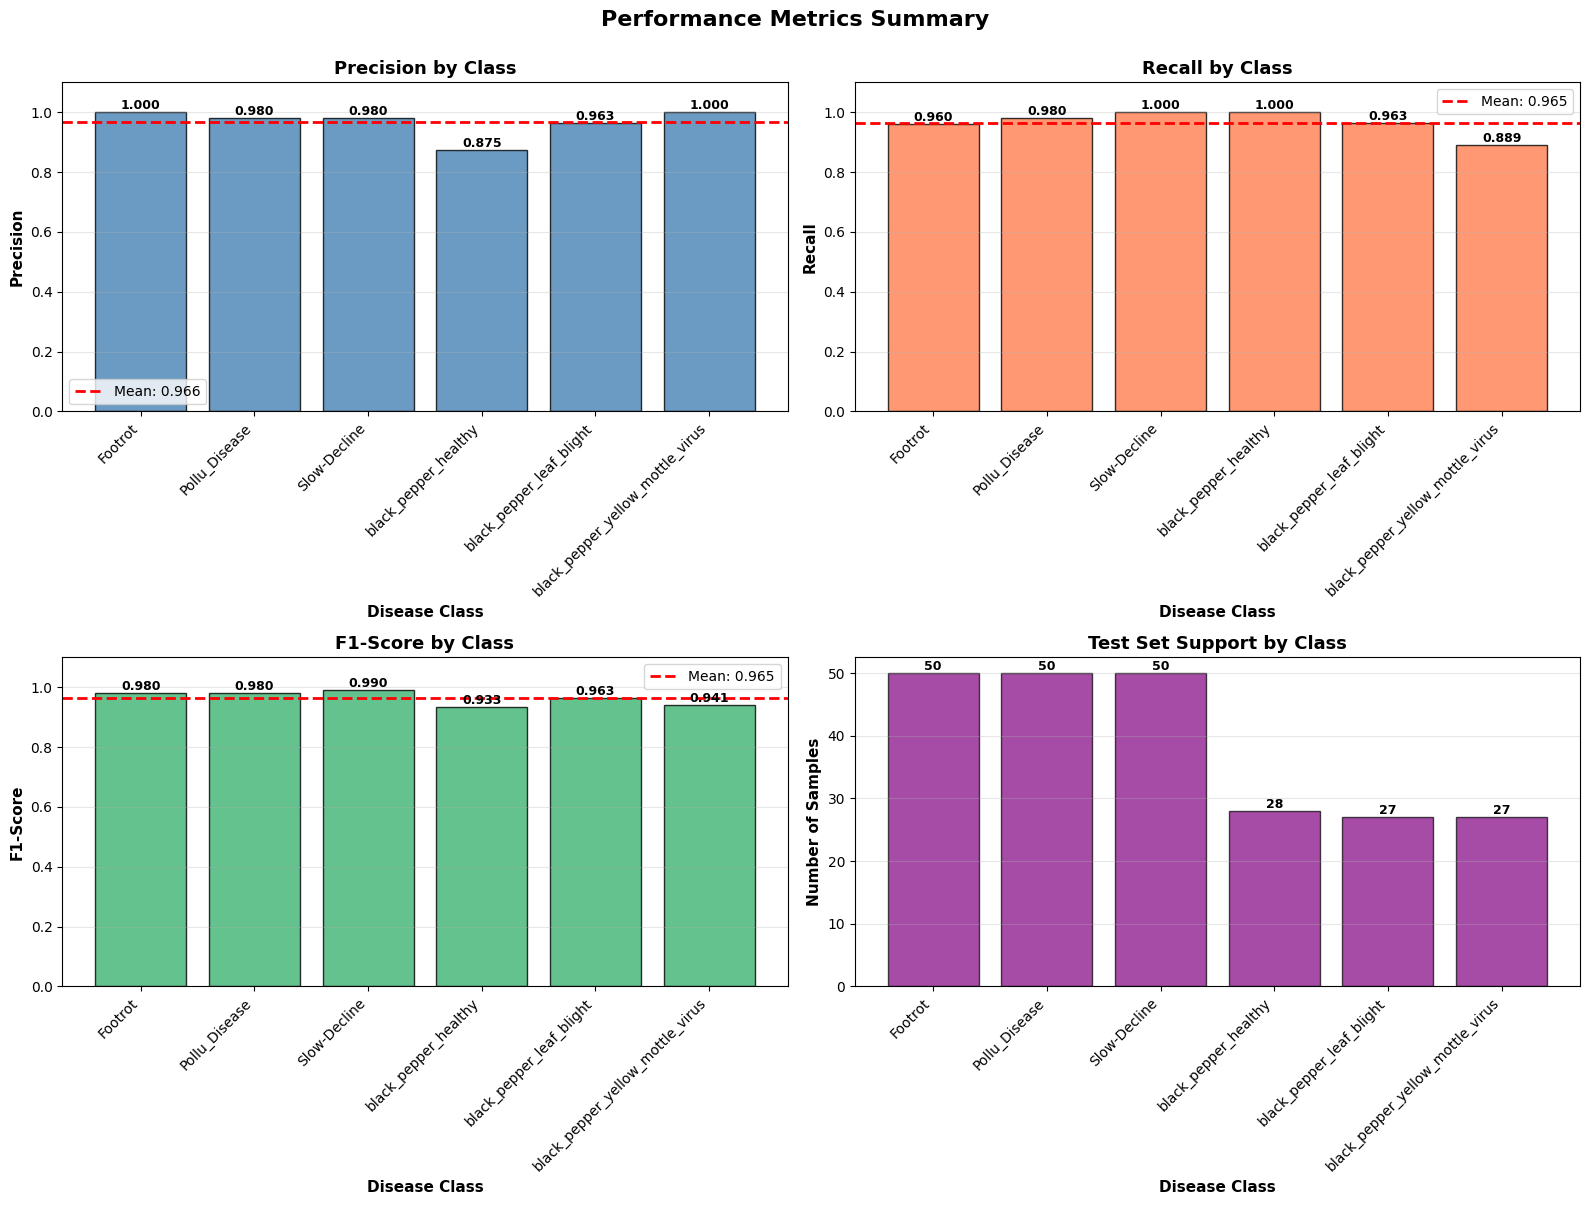

In [25]:
# Visualize metrics per class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'mediumseagreen']

# Plot each metric
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(class_names, report_df[metric], color=color, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Disease Class', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.axhline(y=report_df[metric].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {report_df[metric].mean():.3f}')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Support plot
ax = axes[1, 1]
bars = ax.bar(class_names, report_df['Support'], color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Disease Class', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax.set_title('Test Set Support by Class', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Performance Metrics Summary', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## ROC Curves and AUC Scores

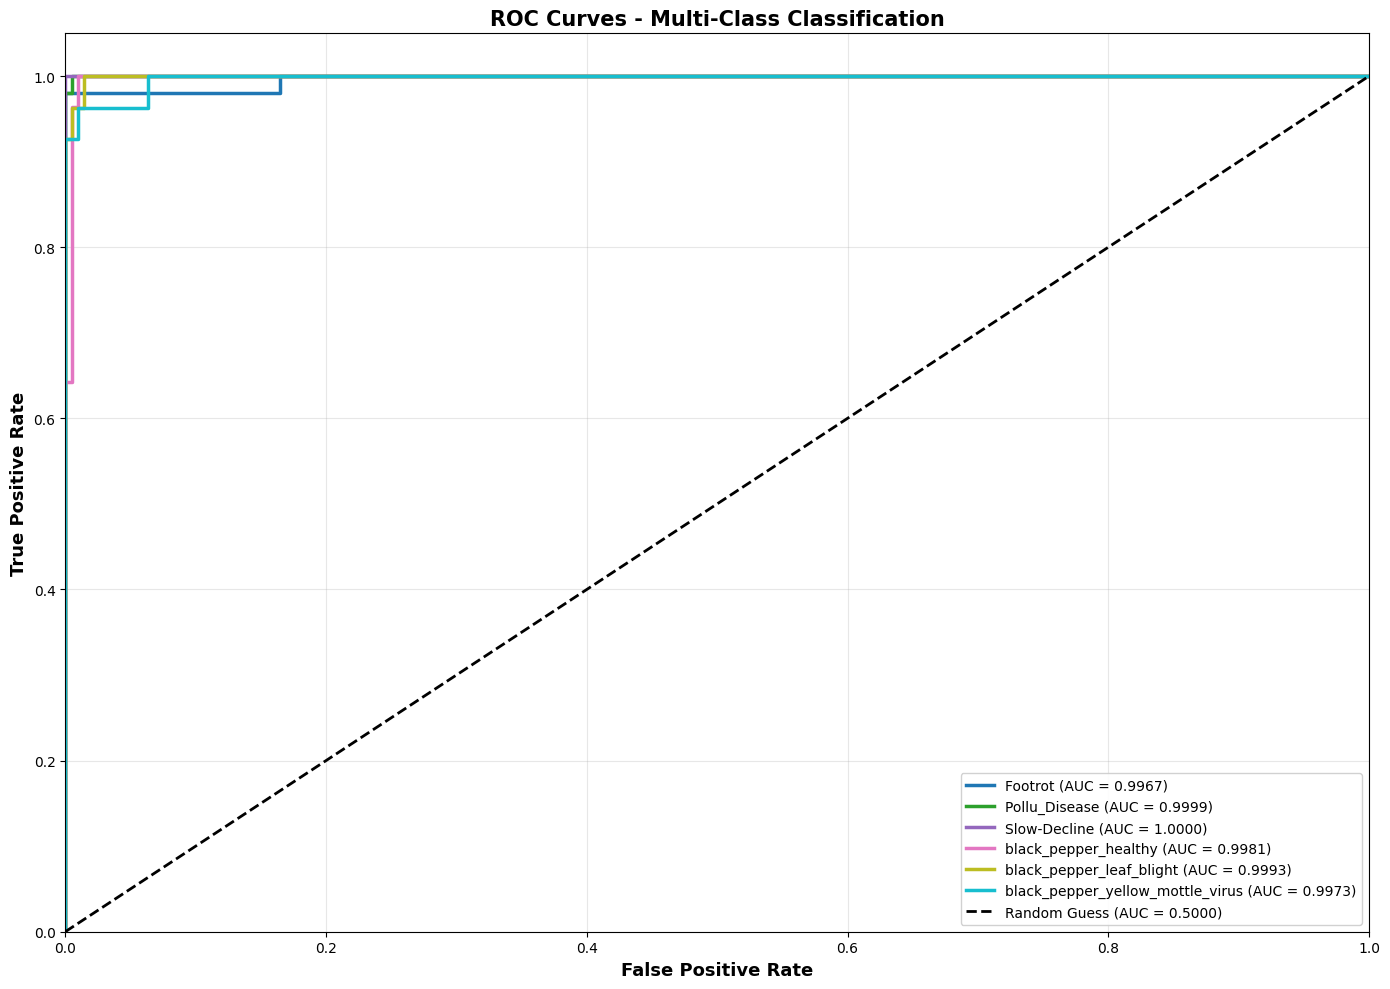


AUC Scores by Class:
Footrot: 0.9967
Pollu_Disease: 0.9999
Slow-Decline: 1.0000
black_pepper_healthy: 0.9981
black_pepper_leaf_blight: 0.9993
black_pepper_yellow_mottle_virus: 0.9973

Mean AUC: 0.9985


In [26]:
# Binarize labels for ROC curve
y_true_binary = label_binarize(y_true, classes=range(num_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Multi-Class Classification', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC scores
print("\nAUC Scores by Class:")
print("=" * 50)
for i in range(num_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
print(f"\nMean AUC: {np.mean(list(roc_auc.values())):.4f}")

## Individual ROC Curves

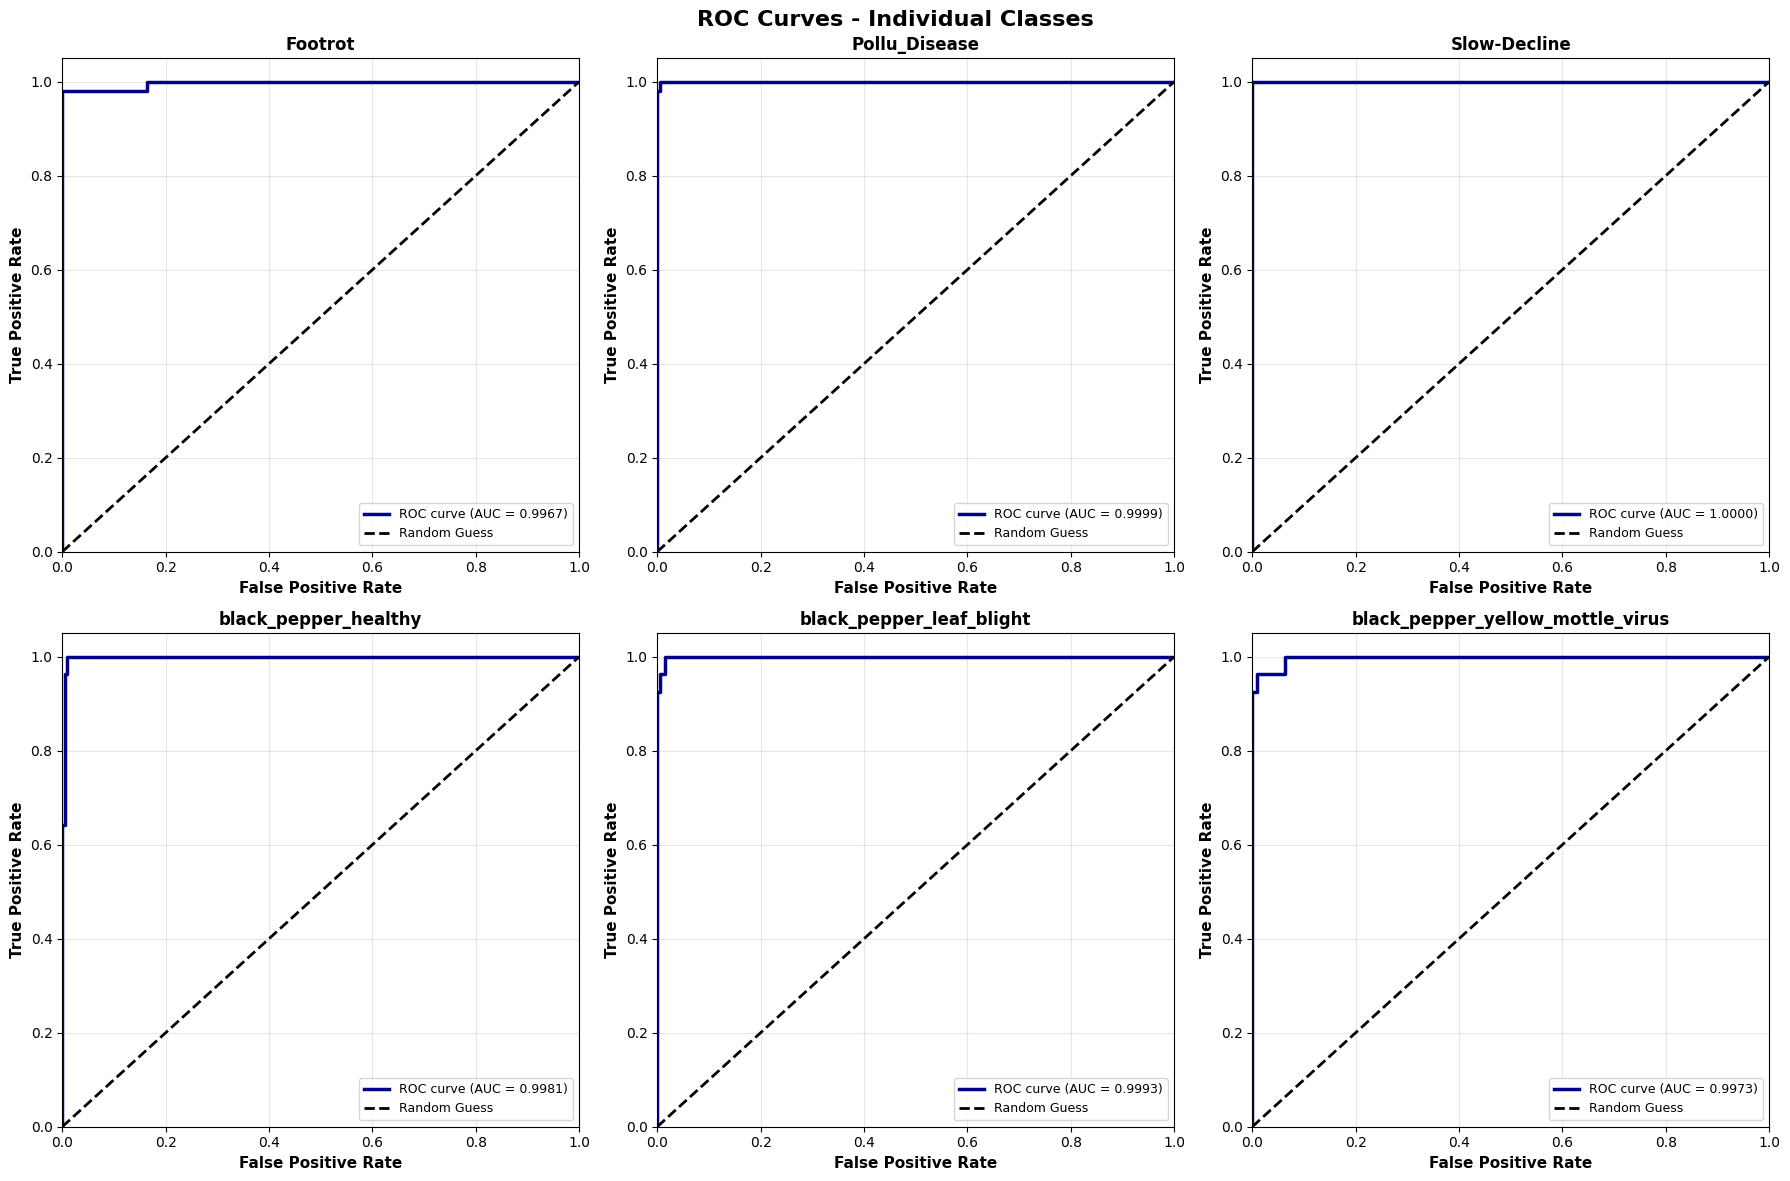

In [27]:
# Plot individual ROC curves in a grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i in range(num_classes):
    axes[i].plot(fpr[i], tpr[i], color='darkblue', lw=2.5, 
                 label=f'ROC curve (AUC = {roc_auc[i]:.4f})')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    axes[i].set_title(f'{class_names[i]}', fontsize=12, fontweight='bold')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('ROC Curves - Individual Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Prediction Examples

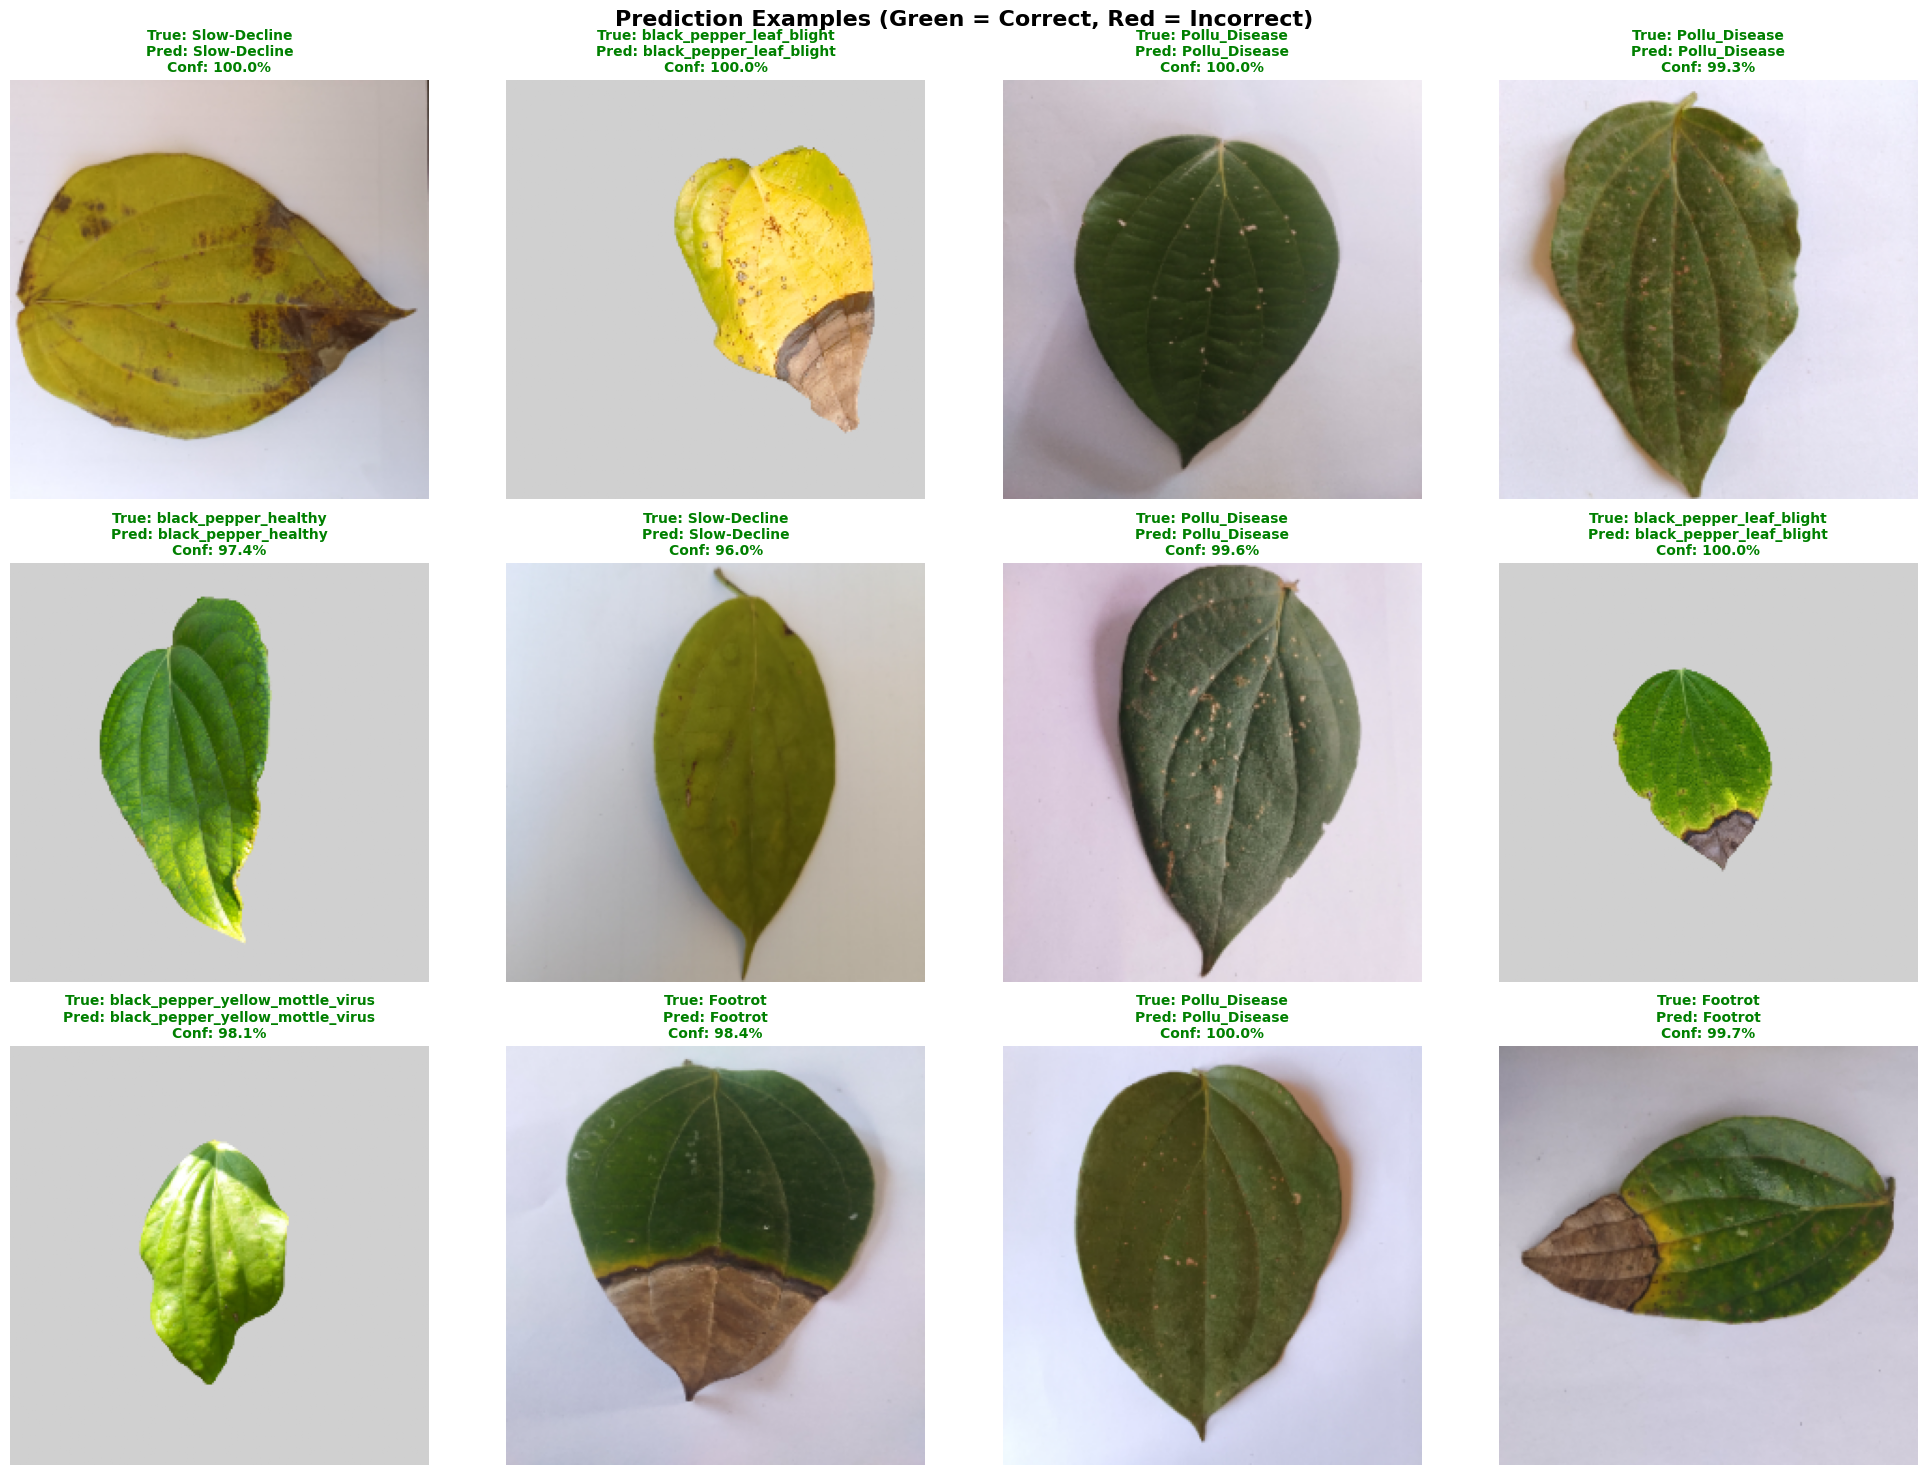

In [28]:
# Function to make predictions
def predict_single(model, img):
    """Make prediction for a single image."""
    img_array = np.expand_dims(img, axis=0)
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100
    return predicted_class, confidence, predictions[0]

# Display random predictions
num_samples = 12
sample_indices = np.random.choice(len(X_test_loaded), num_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for idx, sample_idx in enumerate(sample_indices):
    img = X_test_loaded[sample_idx]
    true_label = class_names[y_test_array[sample_idx]]
    
    predicted_class, confidence, _ = predict_single(model, img)
    
    # Determine color based on correctness
    is_correct = (predicted_class == true_label)
    color = 'green' if is_correct else 'red'
    
    axes[idx].imshow(img)
    axes[idx].set_title(
        f'True: {true_label}\nPred: {predicted_class}\nConf: {confidence:.1f}%',
        fontsize=10, fontweight='bold', color=color
    )
    axes[idx].axis('off')
    
    # Add border
    for spine in axes[idx].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.suptitle('Prediction Examples (Green = Correct, Red = Incorrect)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Prediction Confidence Analysis

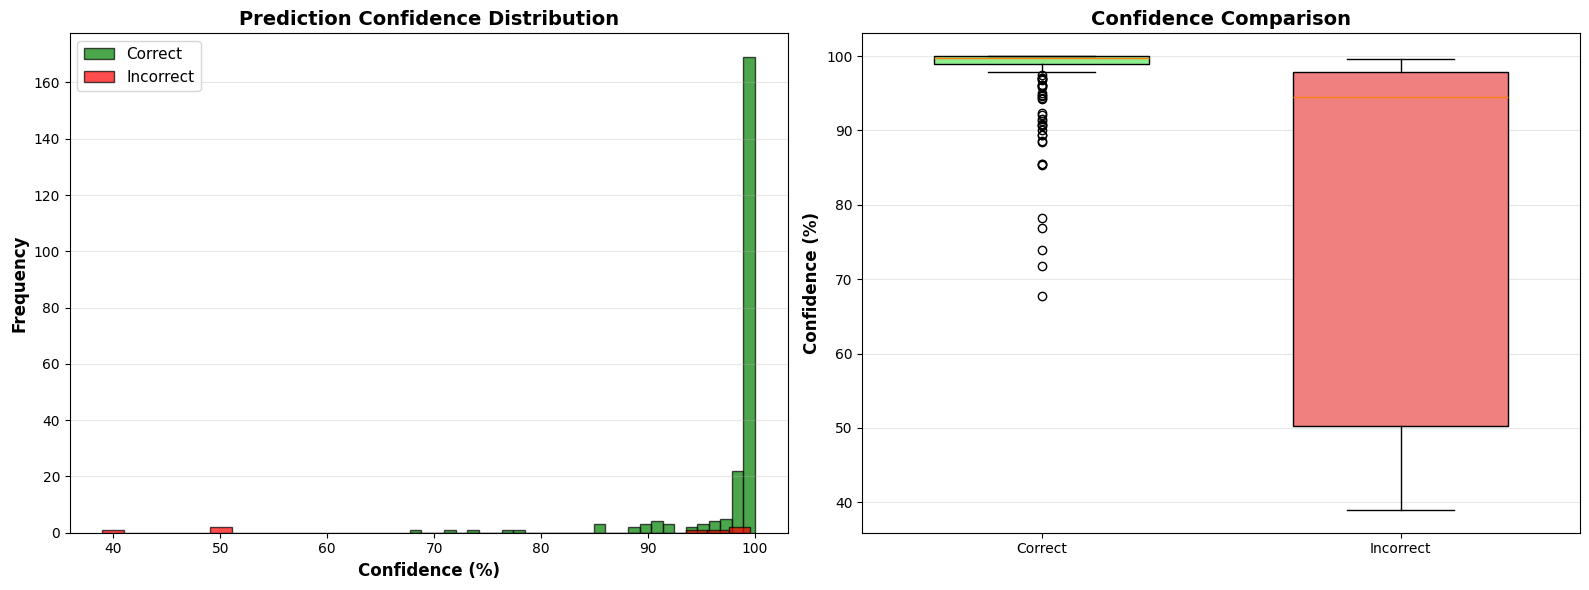


Confidence Statistics:
Correct Predictions:
  Mean confidence: 98.13%
  Median confidence: 99.74%
  Std deviation: 4.63%

Incorrect Predictions:
  Mean confidence: 75.59%
  Median confidence: 94.49%
  Std deviation: 25.49%


In [29]:
# Analyze prediction confidence
max_confidences = np.max(y_pred_proba, axis=1) * 100
correct_predictions = (y_pred == y_true)

correct_confidences = max_confidences[correct_predictions]
incorrect_confidences = max_confidences[~correct_predictions]

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Box plot
box_data = [correct_confidences, incorrect_confidences]
bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'],
                     patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Confidence (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Confidence Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nConfidence Statistics:")
print("=" * 50)
print(f"Correct Predictions:")
print(f"  Mean confidence: {np.mean(correct_confidences):.2f}%")
print(f"  Median confidence: {np.median(correct_confidences):.2f}%")
print(f"  Std deviation: {np.std(correct_confidences):.2f}%")
print(f"\nIncorrect Predictions:")
print(f"  Mean confidence: {np.mean(incorrect_confidences):.2f}%" if len(incorrect_confidences) > 0 else "  N/A")
print(f"  Median confidence: {np.median(incorrect_confidences):.2f}%" if len(incorrect_confidences) > 0 else "  N/A")
print(f"  Std deviation: {np.std(incorrect_confidences):.2f}%" if len(incorrect_confidences) > 0 else "  N/A")

## Save Model

In [30]:
# Save the final model
model.save('pepper_disease_classifier_final.keras')
print("\nModel saved as 'pepper_disease_classifier_final.keras'")

# Save model architecture as JSON
model_json = model.to_json()
with open('model_architecture.json', 'w') as json_file:
    json_file.write(model_json)
print("Model architecture saved as 'model_architecture.json'")

# Save class names
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print("Class names saved as 'class_names.json'")


Model saved as 'pepper_disease_classifier_final.keras'
Model architecture saved as 'model_architecture.json'
Class names saved as 'class_names.json'


## Model Summary and Final Statistics

In [31]:
# Final summary
print("\n" + "="*80)
print("MODEL TRAINING SUMMARY")
print("="*80)
print(f"\nDataset Information:")
print(f"  Total images: {len(image_paths)}")
print(f"  Number of classes: {num_classes}")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Image size: {IMG_HEIGHT}x{IMG_WIDTH}x{CHANNELS}")

print(f"\nTraining Configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Initial learning rate: {LEARNING_RATE}")
print(f"  Epochs trained: {len(history.history['loss'])}")
print(f"  Class imbalance handled: Yes (class weights applied)")
print(f"  Data augmentation: Yes")

print(f"\nFinal Performance:")
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Mean AUC Score: {np.mean(list(roc_auc.values())):.4f}")

print(f"\nPer-Class Performance:")
for i in range(num_classes):
    print(f"  {class_names[i]}:")
    print(f"    Precision: {precision[i]:.4f}")
    print(f"    Recall: {recall[i]:.4f}")
    print(f"    F1-Score: {f1[i]:.4f}")
    print(f"    AUC: {roc_auc[i]:.4f}")

print("\n" + "="*80)
print("Training completed successfully!")
print("="*80)


MODEL TRAINING SUMMARY

Dataset Information:
  Total images: 2319
  Number of classes: 6
  Training samples: 1623
  Validation samples: 464
  Test samples: 232
  Image size: 224x224x3

Training Configuration:
  Batch size: 32
  Initial learning rate: 0.001
  Epochs trained: 41
  Class imbalance handled: Yes (class weights applied)
  Data augmentation: Yes

Final Performance:
  Test Accuracy: 96.98%
  Test Loss: 0.1084
  Mean AUC Score: 0.9985

Per-Class Performance:
  Footrot:
    Precision: 1.0000
    Recall: 0.9600
    F1-Score: 0.9796
    AUC: 0.9967
  Pollu_Disease:
    Precision: 0.9800
    Recall: 0.9800
    F1-Score: 0.9800
    AUC: 0.9999
  Slow-Decline:
    Precision: 0.9804
    Recall: 1.0000
    F1-Score: 0.9901
    AUC: 1.0000
  black_pepper_healthy:
    Precision: 0.8750
    Recall: 1.0000
    F1-Score: 0.9333
    AUC: 0.9981
  black_pepper_leaf_blight:
    Precision: 0.9630
    Recall: 0.9630
    F1-Score: 0.9630
    AUC: 0.9993
  black_pepper_yellow_mottle_virus:
    Pr